In [1]:
import pandas as pd
import numpy as np
import scanpy
import phate
import scprep
import matplotlib.pyplot as plt
import magic
import leidenalg
import seaborn as sns
from sklearn.preprocessing import scale
import pandas as pd
acute = scanpy.read_h5ad('data/acute_tcells.h5ad')
chronic = scanpy.read_h5ad('data/chronic_tcells.h5ad')

/home/aarthivenkat/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
acute = scanpy.read_h5ad('data/acute_tcells.h5ad')
chronic = scanpy.read_h5ad('data/chronic_tcells.h5ad')

In [4]:
adata = scanpy.concat((acute,chronic))
adata.obs['batch'] = adata.obs['batch'].astype('category')

In [4]:
phate_op = phate.PHATE(random_state=42, n_jobs=-1, knn=30)
adata.obsm['X_phate'] = phate_op.fit_transform(adata.to_df())

Calculating PHATE...
  Running PHATE on 39704 observations and 14152 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 17.85 seconds.
    Calculating KNN search...
    Calculated KNN search in 49.09 seconds.
    Calculating affinities...
    Calculated affinities in 5.85 seconds.
  Calculated graph and diffusion operator in 73.29 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 15.44 seconds.
    Calculating KMeans...
    Calculated KMeans in 9.94 seconds.
  Calculated landmark operator in 27.22 seconds.
  Calculating optimal t...
    Automatically selected t = 20
  Calculated optimal t in 1.77 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.41 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 4.14 seconds.
Calculated PHATE in 106.86 seconds.


In [6]:
gene_embedding_results = np.load('results/GSPA_QR_without_regression.npz', allow_pickle=True)

In [7]:
data_ae = gene_embedding_results['signal_embedding']
localization = gene_embedding_results['localization_score']
hvgs = gene_embedding_results['genes']

In [8]:
gene_phate_op = phate.PHATE(random_state=42)
data_phate = gene_phate_op.fit_transform(data_ae)

Calculating PHATE...
  Running PHATE on 1416 observations and 128 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.03 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.19 seconds.
    Calculating affinities...
    Calculated affinities in 0.02 seconds.
  Calculated graph and diffusion operator in 0.24 seconds.
  Calculating optimal t...
    Automatically selected t = 24
  Calculated optimal t in 0.65 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.27 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.76 seconds.
Calculated PHATE in 2.93 seconds.


In [9]:
magic_op = magic.MAGIC()
data_magic = magic_op.fit_transform(adata.to_df(), genes=hvgs, graph=phate_op.graph)

Calculating MAGIC...
  Running MAGIC on 39704 cells and 14152 genes.
  Using precomputed graph and diffusion operator...


/home/aarthivenkat/.local/lib/python3.8/site-packages/magic/magic.py:425: UserWarning: Input matrix contains unexpressed genes. Please remove them prior to running MAGIC.
  warnings.warn(


  Calculating imputation...
  Calculated imputation in 19.27 seconds.
Calculated MAGIC in 20.46 seconds.


## localization

In [10]:
localization = pd.Series(localization, index=hvgs)

In [14]:
cell_clusters = np.array(leidenalg.find_partition(phate_op.graph.to_igraph(), 
                                                  leidenalg.ModularityVertexPartition,
                                                  seed=0).membership)

<AxesSubplot:>

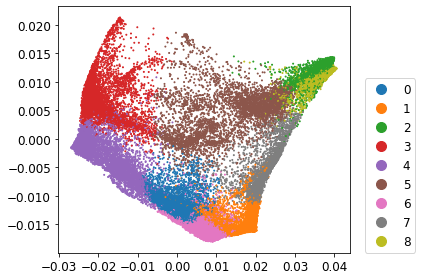

In [15]:
scprep.plot.scatter2d(adata.obsm['X_phate'], c=cell_clusters, legend_loc=(1.05,0))

In [16]:
adata.obs['clusters'] = cell_clusters.astype(str)

In [17]:
scanpy.tl.rank_genes_groups(adata, groupby='clusters', method='wilcoxon')

In [22]:
genes_max_score_clustering = []
for gene in hvgs:
    max_score = -1
    for cluster in [str(x) for x in range(cell_clusters.max() + 1)]:
        score = dict(zip(adata.uns['rank_genes_groups']['names'][cluster], 
                         adata.uns['rank_genes_groups']['scores'][cluster]))[gene]
        if score > max_score:
            max_score = score
    genes_max_score_clustering.append(max_score)

In [2]:
gene_summary = pd.read_csv('results/gene_summary.csv', index_col=0)

In [25]:
gene_summary['clustering_rank'] = genes_max_score_clustering

In [26]:
gene_summary.to_csv('results/gene_summary.csv')

In [32]:
gene_summary[gene_summary.columns[2:]].corr(method='spearman')

,localization_score,clustering_rank
localization_score,1.000000,0.326632
clustering_rank,0.326632,1.000000


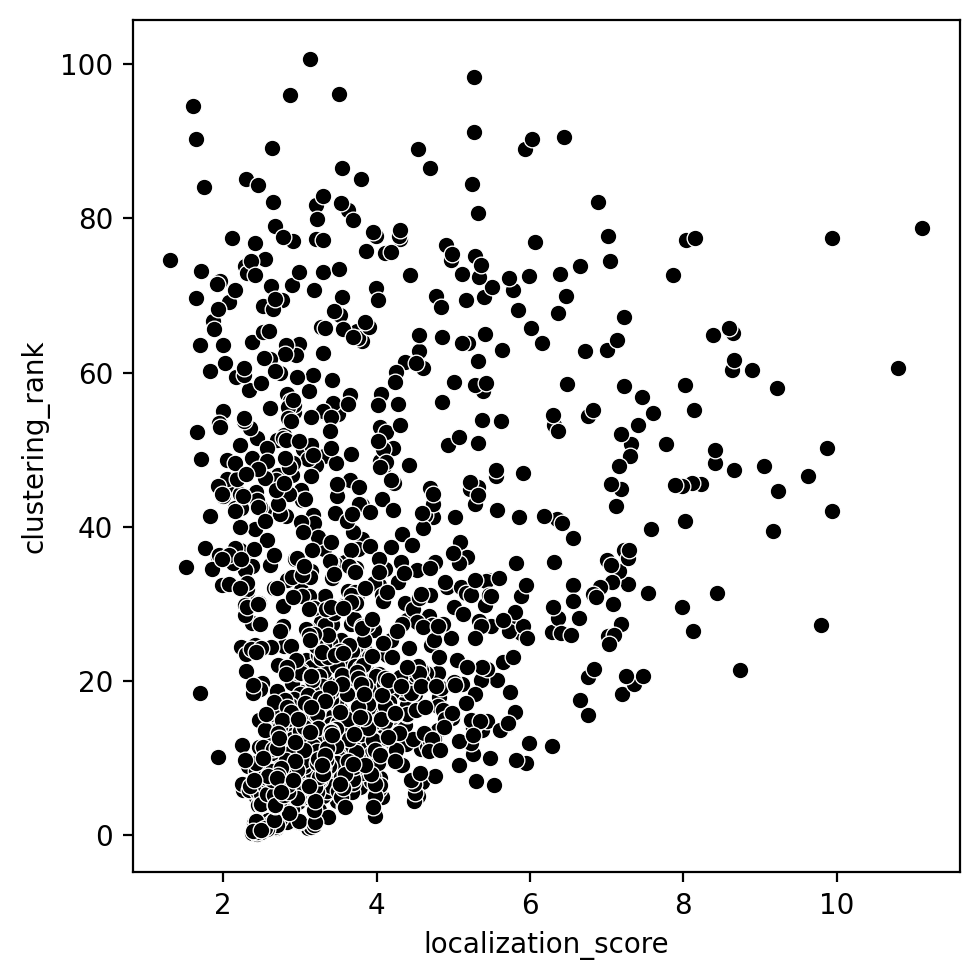

In [37]:
fig, ax = plt.subplots(figsize=(5,5), dpi=200)
sns.scatterplot(x=gene_summary['localization_score'], y=gene_summary['clustering_rank'], ax=ax, color='black')
plt.tight_layout()
fig.savefig('figures/localization_vs_clustering.png', dpi=200)

In [67]:
gene_summary.set_index('Unnamed: 0', inplace=True)

In [71]:
gene_summary['localization_score'].loc[[gene]]

Unnamed: 0
Gzma    11.117589
Name: localization_score, dtype: float64

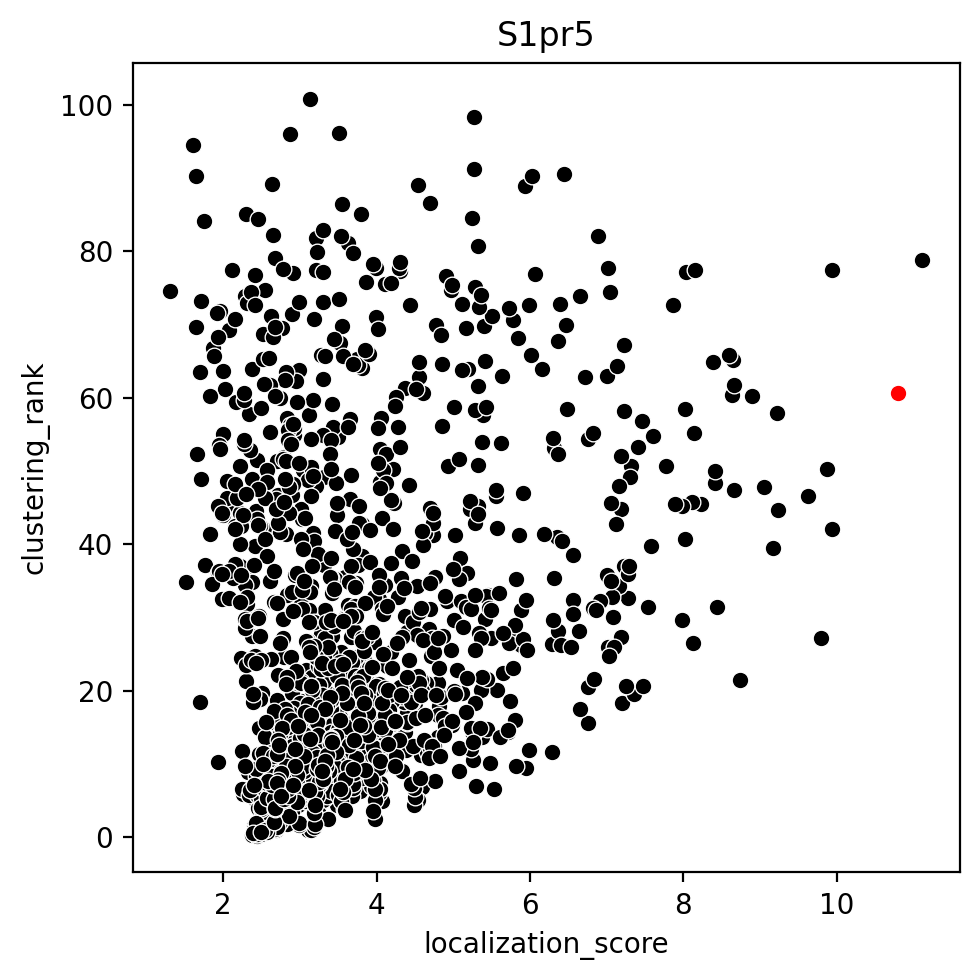

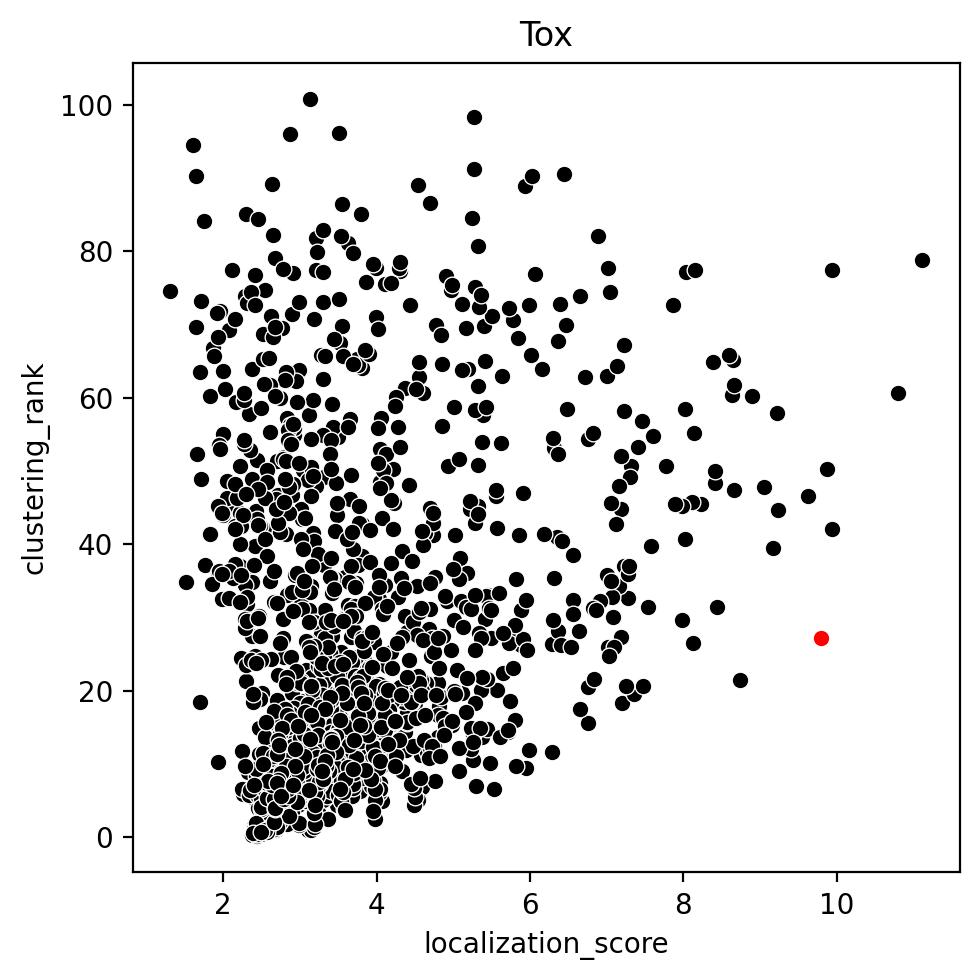

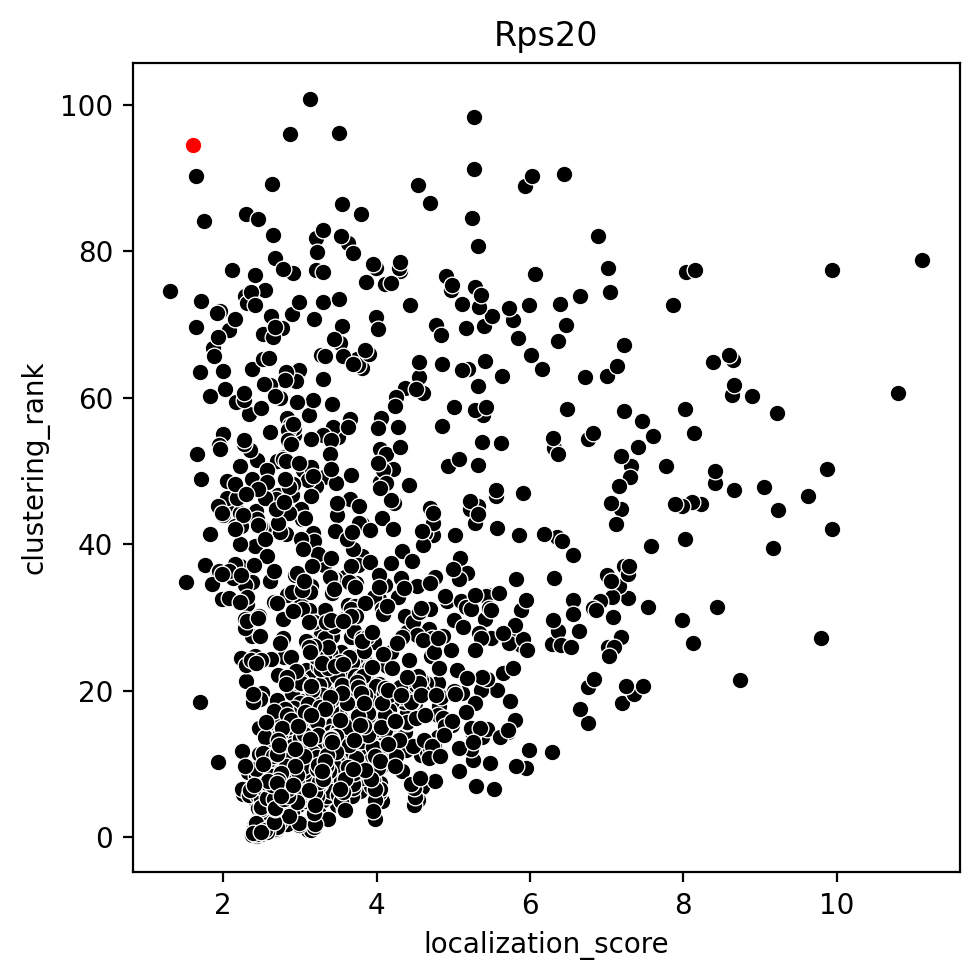

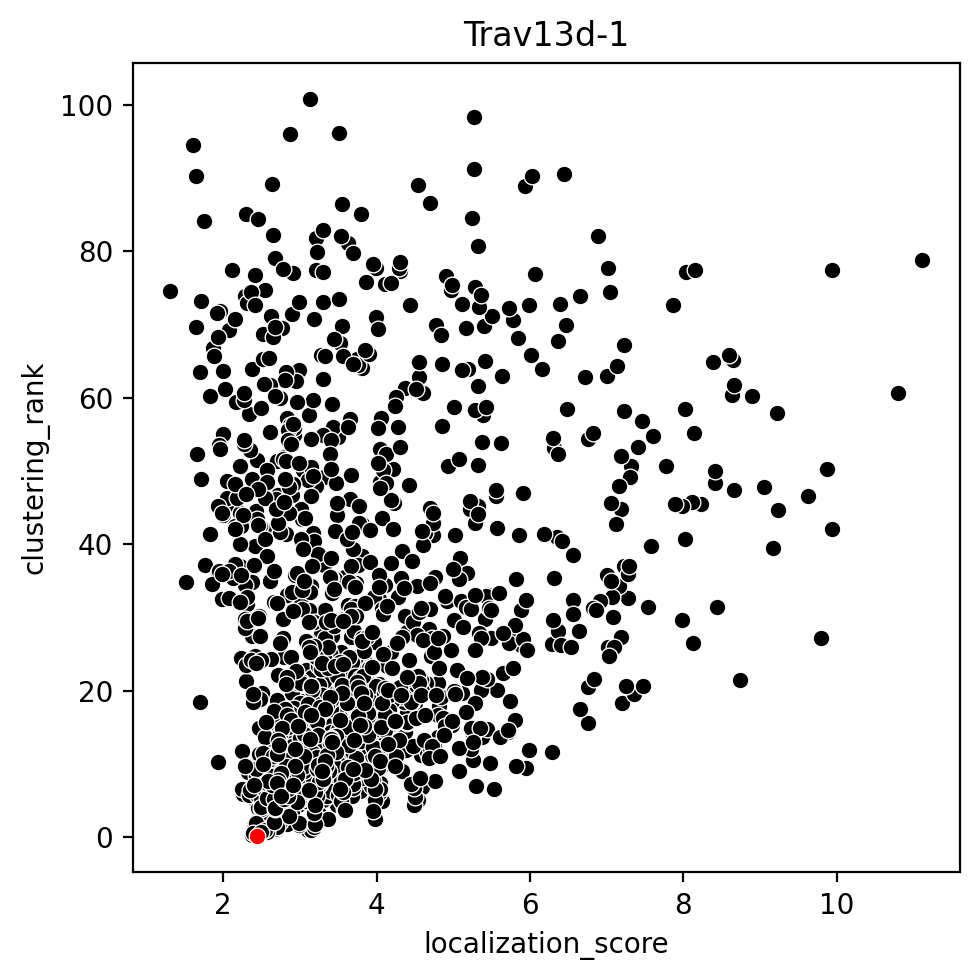

In [77]:
for gene in ['S1pr5', 'Tox', 'Rps20', 'Trav13d-1']:
    fig, ax = plt.subplots(figsize=(5,5), dpi=200)
    sns.scatterplot(x=gene_summary['localization_score'], y=gene_summary['clustering_rank'], ax=ax, 
                    color='black')
    sns.scatterplot(x=gene_summary['localization_score'].loc[[gene]], y=gene_summary['clustering_rank'].loc[[gene]], ax=ax, 
                    color='red')
    plt.title(gene)
    plt.tight_layout()

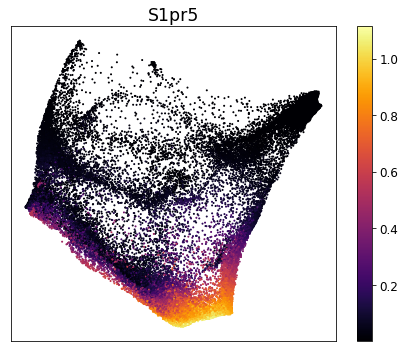

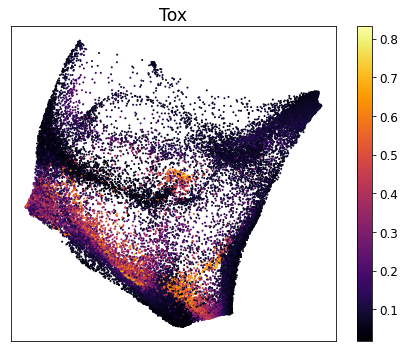

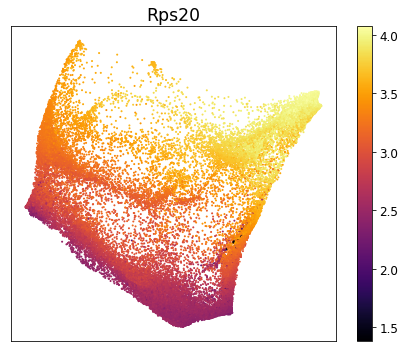

In [ ]:
for gene in ['S1pr5', 'Tox', 'Rps20', 'Trav13d-1']:
    scprep.plot.scatter2d(adata.obsm['X_phate'], c=data_magic[gene], title=gene, ticks=None, figsize=(6,5),
                          dpi=200, filename=f'figures/{gene}.png')